# 02_Diffraction_Sorting_SSA_v7
move away from previous methods to develop a human visual triage approach.

This notebook implements a three-stage pipeline and prepares features for future ML-assisted sorting.

**Notebook cell index:**
1. Cell 1: Imports and Set Up
2. Cell 2: User inputs
3. Cell 3: Pixium Loader (data ingestion)
4. Cell 4: Test loader with a sample file
5. Cell 5: Load all frames into memory
6. Cell 6: Visual Triage (interactive labeling)
7. Cell 7: Organise Files Based on Labels (optional)
8. Cell 8: Feature Extraction (ML-ready)
9. Cell 9: Summary Statistics

Use the numbered cells to navigate quickly when running or reviewing the notebook.

In [1]:
# Cell 1: Imports and Set Up

#standard libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import fabio
from tqdm import tqdm

# for HDF/NXS file reading 
import h5py

import pyFAI

# For interactive widgets
import ipywidgets as widgets
from IPython.display import display, clear_output, Javascript

In [61]:
# Cell 2: User inputs 
data_folder = "E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/" #<-- change path as needed and make sure all \ are replaced with /
output_folder = "E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/02_V7_diff_sorting_output"  # Change this path as needed

# Create output folders if they don't exist
os.makedirs(output_folder, exist_ok=True)
os.makedirs(os.path.join(output_folder, 'processed'), exist_ok=True)

print(f"Raw data folder: {data_folder}")
print(f"Output folder: {output_folder}")


Raw data folder: E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/
Output folder: E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/02_V7_diff_sorting_output


In [62]:
# Cell 3 : Pixium Loader - Data Ingestion 
def load_pixium_frames(filepath):
    """
    Load detector image from I11 Pixium NeXus, HDF5, or standard formats.
    Always returns a 2D numpy array.
    """
    ext = filepath.lower()

    try:
        if ext.endswith((".hdf", ".h5", ".nxs")):
            with h5py.File(filepath, "r") as f:

                # ✅ Explicit known Pixium paths (ORDER MATTERS)
                known_paths = [
                    "entry/data/data",                 # <-- YOUR FILES
                    "entry1/data/data",
                    "entry1/Pixium10:detector/data",
                    "entry/Pixium10:detector/data",
                    "entry1/detector/data",
                    "entry/detector/data",
                ]

                for path in known_paths:
                    if path in f:
                        data = f[path][()]
                        if data.ndim == 3:
                            return data[0]
                        elif data.ndim == 2:
                            return data

                # 🔁 Fallback: search ANY 2D/3D dataset
                candidate = None

                def find_dataset(name, obj):
                    nonlocal candidate
                    if isinstance(obj, h5py.Dataset):
                        if obj.ndim == 2:
                            candidate = obj[()]
                            raise StopIteration
                        elif obj.ndim == 3 and candidate is None:
                            candidate = obj[0]

                try:
                    f.visititems(find_dataset)
                except StopIteration:
                    pass

                if candidate is not None:
                    return candidate

                raise ValueError("No suitable detector dataset found")

        elif ext.endswith((".tif", ".tiff", ".cbf")):
            return fabio.open(filepath).data

        else:
            raise ValueError(f"Unsupported file type: {filepath}")

    except Exception as e:
        raise RuntimeError(f"Failed to load {filepath}: {e}")


Testing loader with: pixium_107757.hdf
✓ Successfully loaded!
  Shape: (2881, 2880)
  Data type: uint32
  Min/Max intensity: 0.00 / 4252.00


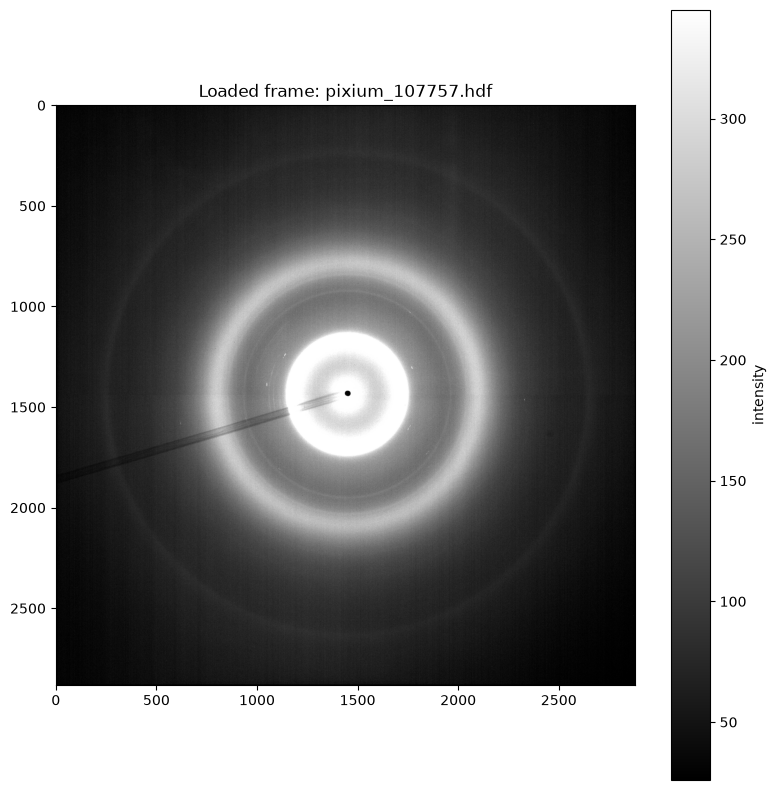

In [63]:
# Cell 4: Test the loader with a sample file
import glob

test_files = sorted(glob.glob(os.path.join(data_folder, "*.hdf")))
if test_files:
    test_file = test_files[0]
    print(f"Testing loader with: {os.path.basename(test_file)}")
    
    img = load_pixium_frames(test_file)
    print(f"✓ Successfully loaded!")
    print(f"  Shape: {img.shape}")
    print(f"  Data type: {img.dtype}")
    print(f"  Min/Max intensity: {img.min():.2f} / {img.max():.2f}")
    
    # Quick visualization
    plt.figure(figsize=(8, 8))
    vmin, vmax = np.percentile(img, [2, 98])
    plt.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    plt.colorbar(label='intensity')
    plt.title(f"Loaded frame: {os.path.basename(test_file)}")
    plt.tight_layout()
    plt.show()
else:
    print(f"❌ No .hdf files found in {data_folder}")

In [64]:
# Cell 5: Load all frames into a list
frames = []
all_files = sorted(glob.glob(os.path.join(data_folder, "*.hdf")))

print(f"Loading {len(all_files)} frames...")
for filepath in tqdm(all_files):
    try:
        img = load_pixium_frames(filepath)
        frames.append({'file': filepath, 'data': img})
    except Exception as e:
        print(f"⚠ Skipped {os.path.basename(filepath)}: {e}")

print(f"✓ Successfully loaded {len(frames)} frames")

Loading 42 frames...


100%|██████████| 42/42 [00:13<00:00,  3.03it/s]

✓ Successfully loaded 42 frames


In [ ]:
# Cell 6: Visual Triage 
def visual_triage(frames, pop_out=False, output_folder=output_folder):
    """
    Visual triage with buttons and keyboard support.
    - Press Y / N / M to mark Diffraction / Background / Ambiguous.
    - If pop_out=True, attempts to use an external matplotlib backend for pop-out windows (may require `%matplotlib qt` or similar).
    Returns a pandas.DataFrame of results once classification is complete.
    """
    results = []
    current_idx = [0]
    output_widget = widgets.Output()

    def record_label(label):
        idx = current_idx[0]
        results.append({'file': frames[idx]['file'], 'label': label})
        with output_widget:
            tag = 'DIFFRACTION' if label == 'y' else ('BACKGROUND' if label == 'n' else 'AMBIGUOUS')
            print(f"✓ Frame {idx+1}/{len(frames)} marked as {tag} - Response recorded!")
        current_idx[0] += 1
        show_next()

    def on_diffraction_clicked(b=None):
        record_label('y')

    def on_background_clicked(b=None):
        record_label('n')

    def on_ambiguous_clicked(b=None):
        record_label('m')

    # Use an ipywidgets Text widget to capture single-key input reliably
    input_widget = widgets.Text(value='', placeholder='Press Y/N/M (focus here)', layout=widgets.Layout(width='260px'))
    def _on_input_change(change):
        v = change.get('new', '')
        if not v:
            return
        k = v.strip().lower()[-1]
        input_widget.value = ''
        if k in ('y', 'n', 'm'):
            record_label(k)
    input_widget.observe(_on_input_change, names='value')
    display(widgets.HBox([input_widget]))
    # Auto-focus the text widget (works in Classic Notebook and JupyterLab)
    display(Javascript("(function(){var inp=document.querySelector('input[placeholder=\\'Press Y/N/M (focus here)\\']'); if(inp){inp.focus();}})();"))

    def show_next():
        output_widget.clear_output(wait=True)
        with output_widget:
            if current_idx[0] >= len(frames):
                print(f"\n✓✓✓ Triage complete! All {len(results)} frames classified.")
                df = pd.DataFrame(results)
                df.to_csv(os.path.join(output_folder, 'classification_log.csv'), index=False)
                print(f"Results saved to: {os.path.join(output_folder, 'classification_log.csv')}")
                display(Javascript("if(window.__jt_keydown){document.removeEventListener('keydown', window.__jt_keydown); window.__jt_keydown = null;}"))
                return

            frame = frames[current_idx[0]]

            if pop_out:
                try:
                    get_ipython().run_line_magic('matplotlib', 'qt')
                except Exception:
                    pass

            fig, ax = plt.subplots(figsize=(10, 8))
            vmin, vmax = np.percentile(frame['data'], [2, 98])
            ax.imshow(frame['data'], cmap='gray', vmin=vmin, vmax=vmax)
            ax.set_title(f"Frame {current_idx[0]+1}/{len(frames)}: {os.path.basename(frame['file'])}", fontsize=14)
            ax.axis('off')
            plt.tight_layout()
            if pop_out:
                try:
                    plt.ion()
                    plt.show(block=False)
                except Exception:
                    plt.show()
            else:
                plt.show()

            # Buttons
            btn_diffraction = widgets.Button(description='[Y] Diffraction', button_style='success', tooltip='Press Y or click')
            btn_background = widgets.Button(description='[N] Background', button_style='danger', tooltip='Press N or click')
            btn_ambiguous = widgets.Button(description='[M] Ambiguous', button_style='warning', tooltip='Press M or click')

            btn_diffraction.on_click(on_diffraction_clicked)
            btn_background.on_click(on_background_clicked)
            btn_ambiguous.on_click(on_ambiguous_clicked)

            display(widgets.HBox([btn_diffraction, btn_background, btn_ambiguous]))

    show_next()
    display(output_widget)

    # Return a DataFrame view of results (will update as user interacts)
    return pd.DataFrame(results)

labels_df = visual_triage(frames)

<IPython.core.display.Javascript object>

Output()

In [66]:
# Cell 7: Organise Files Based on Labels (robust + NXS pairing)

import shutil
import time
import re
import glob
from pathlib import Path

def copy_classified_files(labels_df=None, data_folder=data_folder, output_folder=output_folder, dry_run=False, timeout=300.0, copy_matching_nxs=True):
    """
    Copy files into subfolders ('diffraction','background','maybe') based on labels.
    Also copies matching i11-1-<collection>.nxs next to each copied pixium_<collection>.hdf.

    - labels_df: optional pandas.DataFrame with columns ['file','label']
    - If labels_df is None or empty, waits for classification_log.csv in output_folder and loads it.
    - dry_run: if True, only prints actions without copying.
    - timeout: seconds to wait for CSV before raising.
    - copy_matching_nxs: if True, copies matching NXS files into same triage folder.
    """

    def _load_from_csv(path, timeout):
        start = time.time()
        while not os.path.exists(path):
            time.sleep(0.2)
            if time.time() - start > timeout:
                raise FileNotFoundError(f"Timed out waiting for {path}")
        return pd.read_csv(path)

    def _extract_collection_id(stem):
        m = re.search(r"(\d+)$", stem)
        return m.group(1) if m else None

    def _build_nxs_lookup(root):
        lookup = {}
        for nxs_path in glob.glob(os.path.join(root, "i11-1-*.nxs")):
            stem = Path(nxs_path).stem
            cid = _extract_collection_id(stem)
            if cid is not None and cid not in lookup:
                lookup[cid] = nxs_path
        return lookup

    if labels_df is None or labels_df.empty:
        csv_path = os.path.join(output_folder, 'classification_log.csv')
        print(f"No in-memory labels found — waiting for {csv_path}...")
        labels_df = _load_from_csv(csv_path, timeout)

    if 'file' not in labels_df.columns or 'label' not in labels_df.columns:
        raise ValueError('labels_df must contain `file` and `label` columns')

    folders = {'y': 'diffraction', 'n': 'background', 'm': 'maybe'}
    for d in set(folders.values()):
        os.makedirs(os.path.join(output_folder, d), exist_ok=True)

    nxs_lookup = _build_nxs_lookup(data_folder) if copy_matching_nxs else {}
    if copy_matching_nxs:
        print(f"Found {len(nxs_lookup)} NXS files in {data_folder} for pairing")

    summary = {
        'hdf_copied': 0,
        'hdf_skipped_exists': 0,
        'hdf_missing_source': 0,
        'nxs_copied': 0,
        'nxs_skipped_exists': 0,
        'nxs_missing_match': 0,
        'nxs_missing_source': 0,
        'errors': 0,
    }

    for _, row in labels_df.iterrows():
        src = row['file']
        lab = row['label']
        tgt_folder = folders.get(lab, 'maybe')
        dst_hdf = os.path.join(output_folder, tgt_folder, os.path.basename(src))

        if not os.path.exists(src):
            print(f"⚠ HDF source missing: {src} — skipping")
            summary['hdf_missing_source'] += 1
            continue

        if os.path.exists(dst_hdf):
            print(f"→ HDF exists: {dst_hdf} (skipping overwrite)")
            summary['hdf_skipped_exists'] += 1
        else:
            print(f"Copying HDF {os.path.basename(src)} → {tgt_folder}/")
            if not dry_run:
                try:
                    shutil.copy2(src, dst_hdf)
                    summary['hdf_copied'] += 1
                except Exception as e:
                    print(f"Failed to copy HDF {src} → {dst_hdf}: {e}")
                    summary['errors'] += 1
                    continue
            else:
                summary['hdf_copied'] += 1

        if copy_matching_nxs:
            hdf_stem = Path(src).stem
            collection_id = _extract_collection_id(hdf_stem)
            if collection_id is None:
                print(f"⚠ Could not parse collection id from HDF: {os.path.basename(src)}")
                summary['nxs_missing_match'] += 1
                continue

            nxs_src = nxs_lookup.get(collection_id)
            if nxs_src is None:
                print(f"⚠ No matching NXS for collection {collection_id} ({os.path.basename(src)})")
                summary['nxs_missing_match'] += 1
                continue

            if not os.path.exists(nxs_src):
                print(f"⚠ NXS source missing on disk: {nxs_src}")
                summary['nxs_missing_source'] += 1
                continue

            dst_nxs = os.path.join(output_folder, tgt_folder, os.path.basename(nxs_src))
            if os.path.exists(dst_nxs):
                print(f"→ NXS exists: {dst_nxs} (skipping overwrite)")
                summary['nxs_skipped_exists'] += 1
                continue

            print(f"Copying NXS {os.path.basename(nxs_src)} → {tgt_folder}/")
            if not dry_run:
                try:
                    shutil.copy2(nxs_src, dst_nxs)
                    summary['nxs_copied'] += 1
                except Exception as e:
                    print(f"Failed to copy NXS {nxs_src} → {dst_nxs}: {e}")
                    summary['errors'] += 1
            else:
                summary['nxs_copied'] += 1

    print('\nCopy summary:')
    for k, v in summary.items():
        print(f" - {k}: {v}")

    return summary


# Usage: will use existing `labels_df` if available; set dry_run=True to test first
copy_classified_files(labels_df=labels_df, data_folder=data_folder, output_folder=output_folder, dry_run=False, copy_matching_nxs=True)

No in-memory labels found — waiting for E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/02_V7_diff_sorting_output\classification_log.csv...
Found 42 NXS files in E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/ for pairing
Copying HDF pixium_107757.hdf → diffraction/
Copying NXS i11-1-107757.nxs → diffraction/
Copying HDF pixium_107759.hdf → diffraction/
Copying NXS i11-1-107759.nxs → diffraction/
Copying HDF pixium_107761.hdf → diffraction/
Copying NXS i11-1-107761.nxs → diffraction/
Copying HDF pixium_107763.hdf → diffraction/
Copying NXS i11-1-107763.nxs → diffraction/
Copying HDF pixium_107767.hdf → diffraction/
Copying NXS i11-1-107767.nxs → diffraction/
Copying HDF pixium_107769.hdf → diffraction/
Copying NXS i11-1-107769.nxs → diffraction/
Copying HDF pixium_107770.hdf → diffraction/
Copying NXS i11-1-107770.nxs → diffraction/
Copying HDF pixium_107772.hdf → diffraction/
Copying NXS i11-1-107772.nxs → diffraction/
Copying HDF pixium_107773.hdf → diffraction/
Copying 

{'hdf_copied': 42,
 'hdf_skipped_exists': 0,
 'hdf_missing_source': 0,
 'nxs_copied': 42,
 'nxs_skipped_exists': 0,
 'nxs_missing_match': 0,
 'nxs_missing_source': 0,
 'errors': 0}

In [67]:
# Cell 8: Feature Extraction (ML-Ready)
# Extract discriminative features from all frames (labeled + unlabeled)
# These features will train the future ML classifier

from scipy import ndimage
from scipy.stats import entropy as scipy_entropy

def extract_features(data):
    """
    Extract statistical features from a 2D detector image.
    Returns dict of features useful for ML classification.
    Designed to distinguish diffraction (sharp peaks/rings) from background (smooth/noisy).
    """
    data = np.asarray(data, dtype=np.float32)
    features = {}
    
    # Basic statistics
    features['mean_intensity'] = np.mean(data)
    features['std_intensity'] = np.std(data)
    features['max_intensity'] = np.max(data)
    features['min_intensity'] = np.min(data)
    
    # Percentile-based (robust to outliers)
    p25, p50, p75, p95 = np.percentile(data, [25, 50, 75, 95])
    features['median_intensity'] = p50
    features['iqr_intensity'] = p75 - p25
    features['high_percentile_ratio'] = p95 / (p50 + 1e-6)  # diffraction = spiky
    
    # Histogram entropy (smooth background = high entropy, sharp peaks = low entropy)
    hist, _ = np.histogram(data.ravel(), bins=32, range=(data.min(), data.max()))
    hist = hist[hist > 0]  # remove zeros
    features['entropy'] = scipy_entropy(hist)
    
    # Edge-based features (diffraction = rings = strong edges)
    edges_x = ndimage.sobel(data, axis=0)
    edges_y = ndimage.sobel(data, axis=1)
    edge_magnitude = np.sqrt(edges_x**2 + edges_y**2)
    features['edge_density'] = np.mean(edge_magnitude)
    features['edge_max'] = np.max(edge_magnitude)
    
    # Radial symmetry indicator (diffraction rings = radially symmetric)
    center_y, center_x = np.array(data.shape) / 2.0
    yy, xx = np.ogrid[:data.shape[0], :data.shape[1]]
    radial_dist = np.sqrt((xx - center_x)**2 + (yy - center_y)**2)
    radial_profile = ndimage.mean(data, labels=np.round(radial_dist).astype(int), 
                                  index=np.unique(np.round(radial_dist).astype(int)))
    if len(radial_profile) > 1:
        features['radial_cv'] = np.std(radial_profile) / (np.mean(radial_profile) + 1e-6)
    else:
        features['radial_cv'] = 0.0
    
    # Skewness (background = symmetric, diffraction = skewed towards bright peaks)
    flat_data = data.ravel()
    mean_val = np.mean(flat_data)
    std_val = np.std(flat_data)
    if std_val > 0:
        skewness = np.mean(((flat_data - mean_val) / std_val) ** 3)
        features['skewness'] = skewness
    else:
        features['skewness'] = 0.0
    
    return features

# Extract features from ALL frames (for training ML classifier later)
all_features = []
print("Extracting features from all frames...")

# Ensure labels are loaded (try CSV if labels_df is empty)
labels_for_lookup = labels_df
if labels_for_lookup.empty or 'file' not in labels_for_lookup.columns:
    csv_path = os.path.join(output_folder, 'classification_log.csv')
    if os.path.exists(csv_path):
        labels_for_lookup = pd.read_csv(csv_path)
        print(f"  Loaded labels from {csv_path}")
    else:
        print(f"  ⚠ No labels found yet; proceeding without labels")
        labels_for_lookup = pd.DataFrame()

for frame in tqdm(frames):
    feats = extract_features(frame['data'])
    feats['file'] = frame['file']
    # Add label if available
    if not labels_for_lookup.empty and 'file' in labels_for_lookup.columns:
        label_row = labels_for_lookup[labels_for_lookup['file'] == frame['file']]
        if not label_row.empty:
            feats['label'] = label_row.iloc[0]['label']
        else:
            feats['label'] = None
    else:
        feats['label'] = None
    all_features.append(feats)

features_df = pd.DataFrame(all_features)
features_csv_path = os.path.join(output_folder, 'processed', 'features_ML.csv')
features_df.to_csv(features_csv_path, index=False)
print(f"✓ Extracted {len(features_df)} frames → {features_csv_path}")
print(f"  Features: {[c for c in features_df.columns if c not in ['file','label']]}")

# Optional: summary of labeled frames
processed_df = features_df[features_df['label'] == 'y'].copy()
if not processed_df.empty:
    print(f"\n{len(processed_df)} diffraction frames labeled")
    processed_df.to_csv(os.path.join(output_folder, 'processed', 'diffraction_features.csv'), index=False)

Extracting features from all frames...
  Loaded labels from E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/02_V7_diff_sorting_output\classification_log.csv


100%|██████████| 42/42 [00:30<00:00,  1.38it/s]


✓ Extracted 42 frames → E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/02_V7_diff_sorting_output\processed\features_ML.csv
  Features: ['mean_intensity', 'std_intensity', 'max_intensity', 'min_intensity', 'median_intensity', 'iqr_intensity', 'high_percentile_ratio', 'entropy', 'edge_density', 'edge_max', 'radial_cv', 'skewness']

42 diffraction frames labeled


In [68]:
# Cell 9: Summary Statistics (printed + saved to .txt)

summary_lines = []

summary_lines.append("\n" + "="*60)
summary_lines.append("DATA COLLECTION SUMMARY")
summary_lines.append("="*60)

total_frames = len(frames)
labeled_frames = len(labels_for_lookup)

summary_lines.append(f"\nTotal frames loaded:        {total_frames}")
summary_lines.append(f"Frames labelled:             {labeled_frames}")

if not labels_for_lookup.empty:
    summary_lines.append("\nLabelling breakdown:")
    diffraction_count = 0

    for label_name, label_code in [('Diffraction', 'y'),
                                   ('Background', 'n'),
                                   ('Ambiguous', 'm')]:
        count = len(labels_for_lookup[labels_for_lookup['label'] == label_code])
        if label_code == 'y':
            diffraction_count = count
        pct = (count / labeled_frames * 100) if labeled_frames > 0 else 0
        summary_lines.append(
            f"  {label_name:12} ({label_code}):  {count:3d} frames  ({pct:5.1f}%)"
        )

    # Diffraction collection percentage (vs total frames)
    diffraction_rate = (diffraction_count / total_frames * 100) if total_frames > 0 else 0
    summary_lines.append(f"\n✓ Diffraction collection rate:  {diffraction_rate:.1f}%")
    summary_lines.append(
        f"  (Crystallographic data: {diffraction_count}/{total_frames} frames)"
    )

summary_lines.append(f"\nFeatures extracted:         {len(features_df)}")
summary_lines.append(f"Output location:            {output_folder}/processed/")
summary_lines.append("="*60)

# ---- Print to console ----
for line in summary_lines:
    print(line)

# ---- Save to text file ----
summary_path = os.path.join(
    output_folder, "processed", "data_collection_summary.txt"
)

with open(summary_path, "w") as f:
    for line in summary_lines:
        f.write(line + "\n")

print(f"\n📄 Summary saved to: {summary_path}")



DATA COLLECTION SUMMARY

Total frames loaded:        42
Frames labelled:             42

Labelling breakdown:
  Diffraction  (y):   42 frames  (100.0%)
  Background   (n):    0 frames  (  0.0%)
  Ambiguous    (m):    0 frames  (  0.0%)

✓ Diffraction collection rate:  100.0%
  (Crystallographic data: 42/42 frames)

Features extracted:         42
Output location:            E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/02_V7_diff_sorting_output/processed/

📄 Summary saved to: E:/I11 Beamtime July 25 - LHIST/RAW_2D/Run_5_X3_0.5VF/02_V7_diff_sorting_output\processed\data_collection_summary.txt
